In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# LeafGuard — Crop Disease Detection: Model Training

End-to-end training notebook: MobileNetV3 transfer learning on the **New Plant Diseases Dataset** (38 classes, ~87K augmented leaf images), followed by fine-tuning, evaluation, and INT8 TFLite export for on-device inference in the Flutter app.

**Before running:** add the dataset via Kaggle's "Add Data" panel — search for `vipoooool/new-plant-diseases-dataset` — and enable a GPU accelerator (Settings → Accelerator → GPU T4 x2 or similar).

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPU available:", gpus)

# Enable memory growth so TF allocates GPU memory incrementally instead of
# grabbing everything upfront -- helps avoid memory-pressure crashes on shared
# Kaggle instances.
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

IMG_SIZE = (224, 224)          # MobileNetV3 default input resolution
BATCH_SIZE = 32
EPOCHS_HEAD = 10               # training with the base model frozen
EPOCHS_FINE_TUNE = 8           # fine-tuning with top base layers unfrozen
LEARNING_RATE_HEAD = 1e-3
LEARNING_RATE_FINE_TUNE = 1e-5

OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [8]:
KAGGLE_INPUT = "/kaggle/input"

print("Top-level items in /kaggle/input:")
for name in os.listdir(KAGGLE_INPUT):
    print(" -", name)

def find_dir(root, target_name):
    for dirpath, dirnames, filenames in os.walk(root):
        if os.path.basename(dirpath).lower() == target_name.lower():
            return dirpath
    return None

# Search the whole /kaggle/input tree rather than guessing the exact dataset
# slug -- Kaggle has several re-uploads of this dataset under different slugs,
# so hardcoding "new-plant-diseases-dataset" isn't reliable.
TRAIN_DIR = find_dir(KAGGLE_INPUT, "train")
VALID_DIR = find_dir(KAGGLE_INPUT, "valid")

print("\nTRAIN_DIR:", TRAIN_DIR)
print("VALID_DIR:", VALID_DIR)

assert TRAIN_DIR is not None, "Could not find a 'train' folder anywhere under /kaggle/input — check the DATASETS panel to confirm the dataset is actually added to this notebook."
assert VALID_DIR is not None, "Could not find a 'valid' folder anywhere under /kaggle/input."


Top-level items in /kaggle/input:
 - datasets

TRAIN_DIR: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
VALID_DIR: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid


In [9]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    VALID_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")
print(class_names)


Found 70295 files belonging to 38 classes.


I0000 00:00:1788240290.425727      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 17572 files belonging to 38 classes.
Number of classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'To

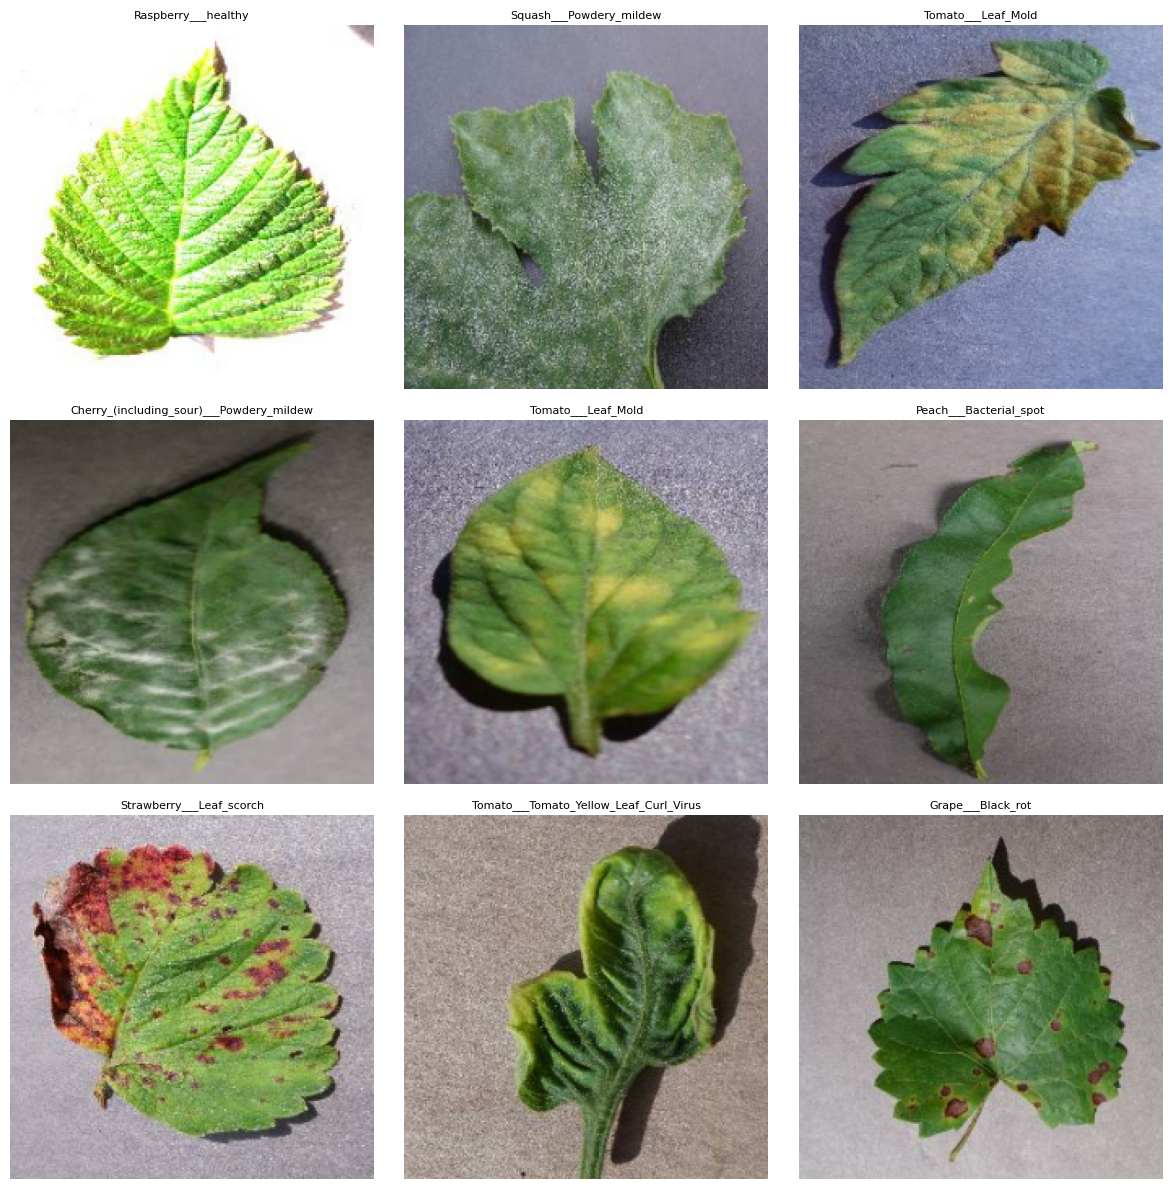

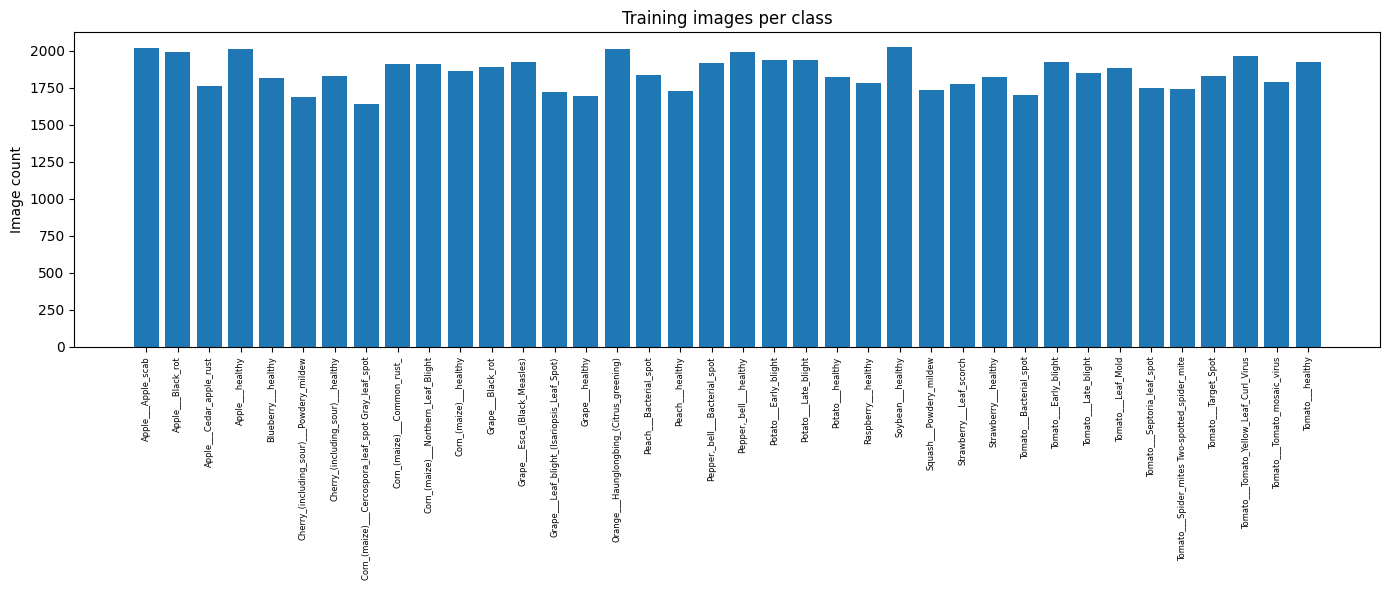

In [10]:
plt.figure(figsize=(12, 12))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_idx = np.argmax(labels[i])
        plt.title(class_names[label_idx], fontsize=8)
        plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sample_images.png"))
plt.show()

class_counts = {cls: len(os.listdir(os.path.join(TRAIN_DIR, cls))) for cls in class_names}
plt.figure(figsize=(14, 6))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90, fontsize=6)
plt.ylabel("Image count")
plt.title("Training images per class")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "class_distribution.png"))
plt.show()


In [12]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
], name="data_augmentation")

AUTOTUNE = tf.data.AUTOTUNE

# IMPORTANT: image_dataset_from_directory() already returns a BATCHED dataset
# (batch_size=32 applied inside that call). So .shuffle(N) here buffers N
# *batches*, not N images -- shuffle(1000) would try to hold 1000*32=32,000
# images (~19GB) in RAM and crash the kernel. Use a small batch-count instead.
SHUFFLE_BUFFER_BATCHES = 50   # 50 batches * BATCH_SIZE(32) = 1,600 images buffered (~1GB)

train_ds = train_ds.shuffle(SHUFFLE_BUFFER_BATCHES).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)


In [13]:
preprocess_input = tf.keras.applications.mobilenet_v3.preprocess_input

base_model = MobileNetV3Large(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
    pooling="avg"
)
base_model.trainable = False  # freeze for the initial head-training phase

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs, name="leafguard_mobilenetv3")
model.summary()


Model: "leafguard_mobilenetv3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 960)            │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,252,134 (12.41 MB)

 Trainable params: 255,782 (999.15 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [2]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_HEAD),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True),
    ModelCheckpoint(
        os.path.join(OUTPUT_DIR, "leafguard_best.keras"),
        monitor="val_accuracy",
        save_best_only=True
    ),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7)
]


NameError: name 'model' is not defined

In [15]:
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks
)


Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 229s 96ms/step - accuracy: 0.8261 - loss: 0.5600 - val_accuracy: 0.9367 - val_loss: 0.1917 - learning_rate: 0.0010
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 109s 48ms/step - accuracy: 0.9022 - loss: 0.2933 - val_accuracy: 0.9501 - val_loss: 0.1475 - learning_rate: 0.0010
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 109s 49ms/step - accuracy: 0.9140 - loss: 0.2575 - val_accuracy: 0.9545 - val_loss: 0.1303 - learning_rate: 0.0010
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 108s 48ms/step - accuracy: 0.9196 - loss: 0.2419 - val_accuracy: 0.9578 - val_loss: 0.1246 - learning_rate: 0.0010
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 108s 48ms/step - accuracy: 0.9234 - loss: 0.2280 - val_accuracy: 0.9638 - val_loss: 0.1100 - learning_rate: 0.0010
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 108s 48ms/step - accuracy: 0.9277 - loss: 0.2169 - val_accuracy: 0.9570 - val_loss: 0.1248 - learning_rate: 0.0010
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 108s 48ms/step -

## Fine-tuning

Unfreeze the top layers of the base model and continue training at a much lower learning rate. This is what pushes accuracy meaningfully above the frozen-base baseline — and it's worth reporting *both* numbers (before/after fine-tuning) in your model card, since that comparison is a good interview talking point.

In [16]:
base_model.trainable = True

# Keep early layers frozen (generic features); only fine-tune the last ~40 layers
fine_tune_at = len(base_model.layers) - 40
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_FINE_TUNE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE_TUNE,
    callbacks=callbacks
)


Epoch 1/8
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 152s 62ms/step - accuracy: 0.8819 - loss: 0.4574 - val_accuracy: 0.9706 - val_loss: 0.0899 - learning_rate: 1.0000e-05
Epoch 2/8
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 139s 62ms/step - accuracy: 0.9405 - loss: 0.1898 - val_accuracy: 0.9763 - val_loss: 0.0737 - learning_rate: 1.0000e-05
Epoch 3/8
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 139s 62ms/step - accuracy: 0.9536 - loss: 0.1389 - val_accuracy: 0.9799 - val_loss: 0.0610 - learning_rate: 1.0000e-05
Epoch 4/8
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 139s 62ms/step - accuracy: 0.9625 - loss: 0.1128 - val_accuracy: 0.9825 - val_loss: 0.0516 - learning_rate: 1.0000e-05
Epoch 5/8
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 138s 62ms/step - accuracy: 0.9670 - loss: 0.1005 - val_accuracy: 0.9840 - val_loss: 0.0468 - learning_rate: 1.0000e-05
Epoch 6/8
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 137s 61ms/step - accuracy: 0.9716 - loss: 0.0834 - val_accuracy: 0.9859 - val_loss: 0.0428 - learning_rate: 1.0000e-05
Epoch 7/8
2197/2197 ━━━━━━━━━━━━━━━━━━━━

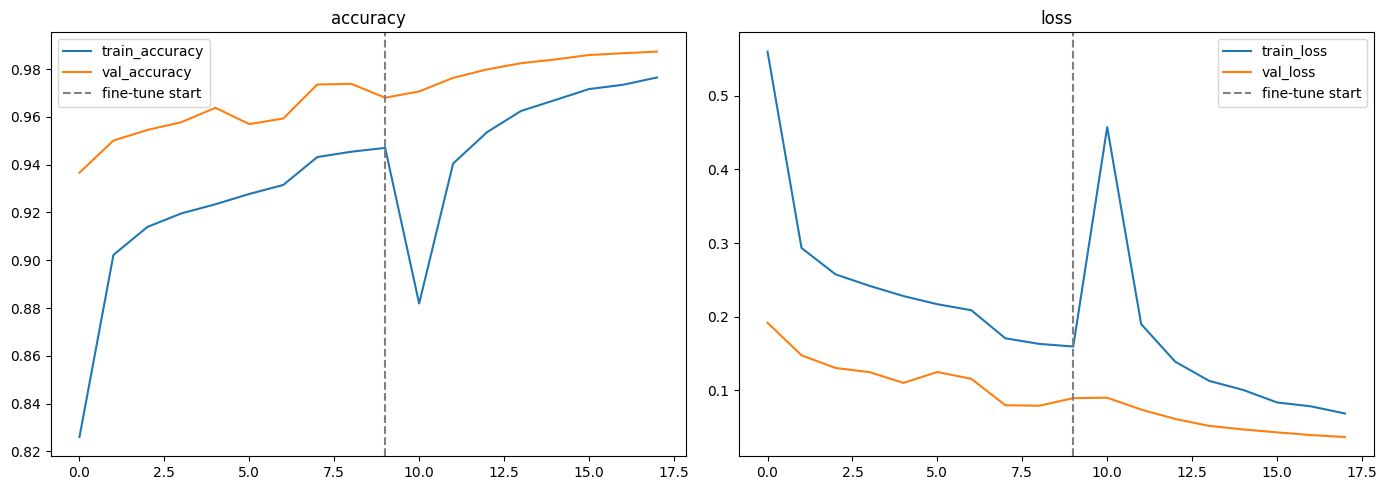

In [17]:
def plot_history(h1, h2, key):
    vals = h1.history[key] + h2.history[key]
    val_vals = h1.history[f"val_{key}"] + h2.history[f"val_{key}"]
    plt.plot(vals, label=f"train_{key}")
    plt.plot(val_vals, label=f"val_{key}")
    plt.axvline(x=len(h1.history[key]) - 1, color="gray", linestyle="--", label="fine-tune start")
    plt.legend()
    plt.title(key)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plot_history(history_head, history_fine, "accuracy")
plt.subplot(1, 2, 2)
plot_history(history_head, history_fine, "loss")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"))
plt.show()


## Evaluation

Don't stop at accuracy — a confusion matrix and per-class report show *which* diseases the model confuses, which matters a lot for a plant-disease app (mixing up two treatable diseases is very different from missing a serious one).

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      0.98      0.99       504
                                 Apple___Black_rot       0.99      1.00      1.00       497
                          Apple___Cedar_apple_rust       1.00      1.00      1.00       440
                                   Apple___healthy       0.99      1.00      0.99       502
                               Blueberry___healthy       1.00      1.00      1.00       454
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       421
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.97      0.91      0.94       410
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       477
               Corn_(maize)___Northern_Leaf_Blight       0.92      0.98      0.

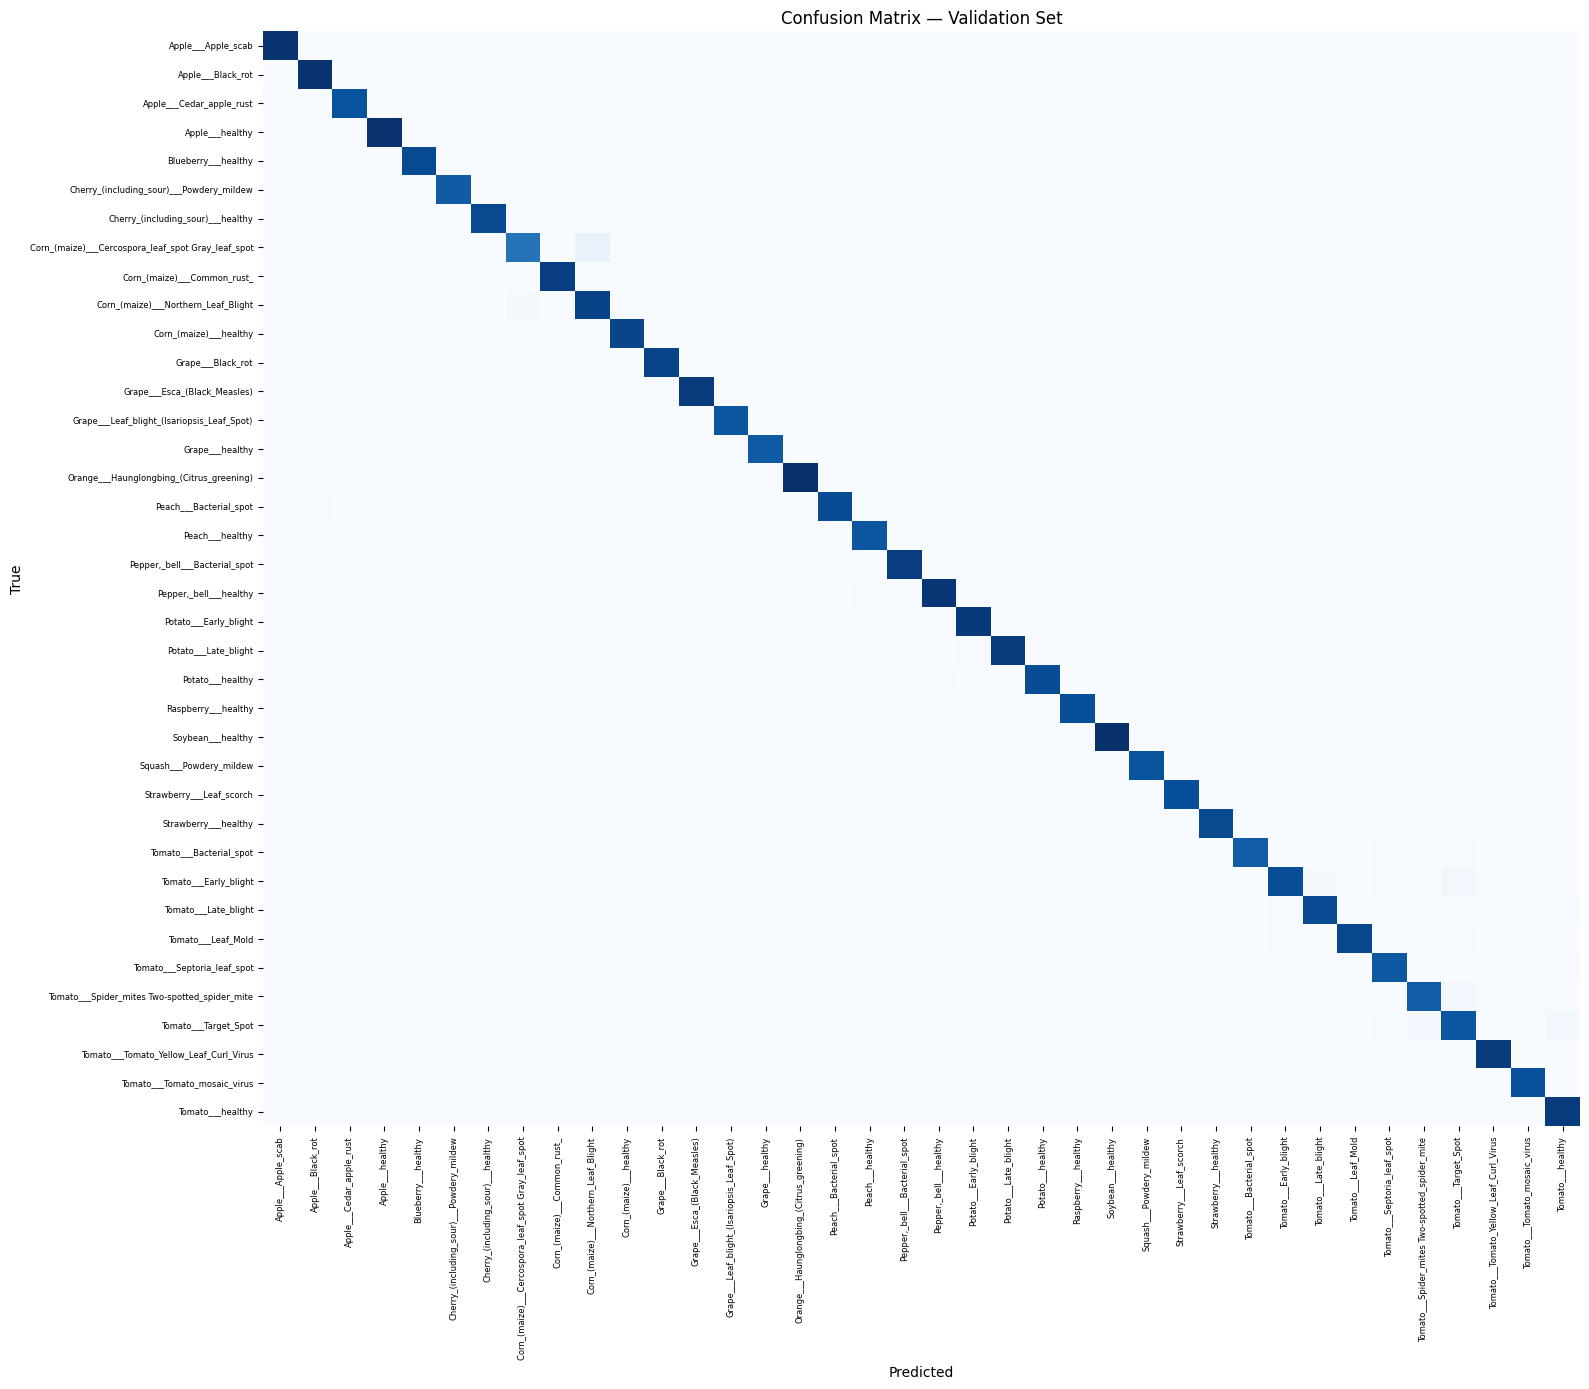

In [18]:
y_true, y_pred = [], []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, xticklabels=class_names, yticklabels=class_names, cmap="Blues", cbar=False)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=6)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Validation Set")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"))
plt.show()


## Save the Keras model and class labels

In [19]:
model.save(os.path.join(OUTPUT_DIR, "leafguard_final.keras"))

with open(os.path.join(OUTPUT_DIR, "labels.txt"), "w") as f:
    for name in class_names:
        f.write(name + "\n")

print("Saved model and labels.txt to", OUTPUT_DIR)


Saved model and labels.txt to /kaggle/working


## Export to TFLite (INT8 quantized)

This is the step that turns a research model into something that actually ships on a phone. INT8 quantization with a representative dataset typically gets the model under 5-10MB with a small (often <2%) accuracy drop — measure and report that drop, don't just assume it.

In [20]:
def representative_dataset():
    for images, _ in train_ds.take(100):
        for img in images:
            img = tf.expand_dims(img, axis=0)
            yield [tf.cast(img, tf.float32).numpy()]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8

tflite_quant_model = converter.convert()

tflite_path = os.path.join(OUTPUT_DIR, "leafguard_v1_int8.tflite")
with open(tflite_path, "wb") as f:
    f.write(tflite_quant_model)

size_mb = os.path.getsize(tflite_path) / (1024 * 1024)
print(f"Quantized TFLite model saved: {tflite_path} ({size_mb:.2f} MB)")


INFO:tensorflow:Assets written to: /tmp/tmplcklida0/assets


INFO:tensorflow:Assets written to: /tmp/tmplcklida0/assets


Saved artifact at '/tmp/tmplcklida0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_204')
Output Type:
  TensorSpec(shape=(None, 38), dtype=tf.float32, name=None)
Captures:
  134522165644176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134522165643408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134522165643024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134522165643600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134522165648400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134522165644560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134522165650512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134522165647632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134522165642064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134522165643216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134522165

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1788198332.802323     260 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1788198332.802379     260 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1788198332.971667     260 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


Quantized TFLite model saved: /kaggle/working/leafguard_v1_int8.tflite (3.58 MB)


fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8


In [22]:
# Sanity-check: run real TFLite inference and compare against ground truth
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

correct, total = 0, 0

for images, labels in val_ds.take(5):
    for i in range(images.shape[0]):
        img = tf.expand_dims(images[i], axis=0)
        if input_details[0]['dtype'] == np.uint8:
            img = tf.cast(img, tf.uint8)
        else:
            img = tf.cast(img, tf.float32)

        interpreter.set_tensor(input_details[0]['index'], img.numpy())
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])

        pred_idx = np.argmax(output)
        true_idx = np.argmax(labels[i].numpy())

        correct += int(pred_idx == true_idx)
        total += 1

print(f"TFLite sanity-check accuracy on {total} samples: {correct/total:.2%}")


RuntimeError: failed to create XNNPACK runtimeNode number 125 (TfLiteXNNPackDelegate) failed to prepare.

In [4]:
# Rebuild a clean, inference-only model for export -- reuses the already-trained
# base_model and head layers (Dropout/Dense), but WITHOUT the data_augmentation
# layer, which is what breaks TFLite/XNNPACK. No retraining needed.

head_layers = [l for l in model.layers if isinstance(l, (tf.keras.layers.Dense, tf.keras.layers.Dropout))]
print("Head layers found (should be Dropout, Dense, Dropout, Dense in order):")
print([l.name for l in head_layers])

export_inputs = tf.keras.Input(shape=IMG_SIZE + (3,), name="export_input")
x = preprocess_input(export_inputs)
x = base_model(x, training=False)
for layer in head_layers:
    x = layer(x)

export_model = tf.keras.Model(export_inputs, x, name="leafguard_export")
export_model.summary()

NameError: name 'model' is not defined

## Done